In [5]:
import pandas as pd
df=pd.read_csv("../data/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [9]:

df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [12]:
for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].unique())
    print()

mainroad
['yes' 'no']

guestroom
['no' 'yes']

basement
['no' 'yes']

hotwaterheating
['no' 'yes']

airconditioning
['yes' 'no']

prefarea
['yes' 'no']

furnishingstatus
['furnished' 'semi-furnished' 'unfurnished']



In [13]:
binary_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_cols:
    df[col] = df[col].map({
        "yes": 1,
        "no": 0
    })


In [14]:
df = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True
)

In [15]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [16]:
corr = df.corr(numeric_only=True)

print(corr["price"].sort_values(ascending=False))

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


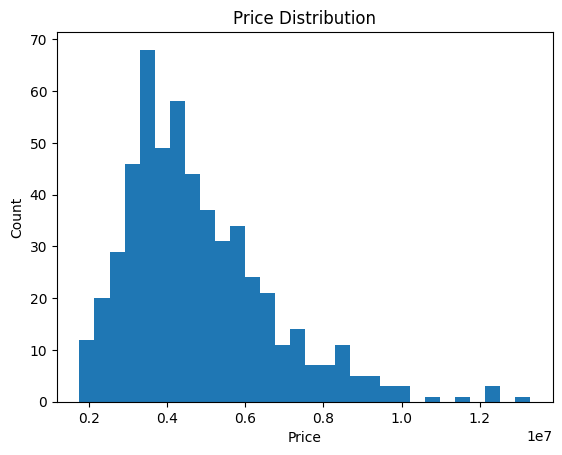

In [17]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=30)

plt.xlabel("Price")
plt.ylabel("Count")

plt.title("Price Distribution")

plt.show()

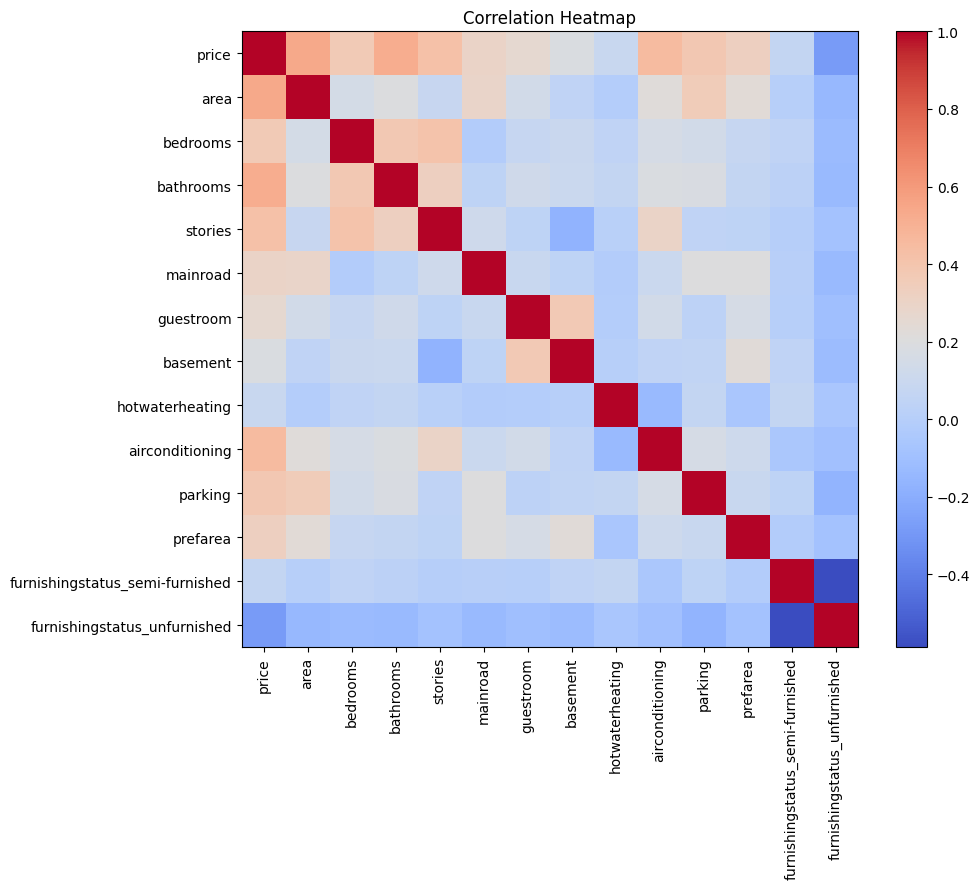

In [18]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
X = df.drop("price", axis=1)

In [20]:
y = df["price"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
pred_lr=lr.predict(X_test)

In [24]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

rmse_lr = mean_squared_error(
    y_test,
    pred_lr,
    squared=False
)

print("Linear Regression RMSE:", rmse_lr)

TypeError: got an unexpected keyword argument 'squared'

In [25]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

mse_lr = mean_squared_error(
    y_test,
    pred_lr
)

rmse_lr = mse_lr ** 0.5

print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 1324506.9600914384


In [26]:
r2_lr = r2_score(
    y_test,
    pred_lr
)

print("Linear Regression R2:", r2_lr)

Linear Regression R2: 0.6529242642153186


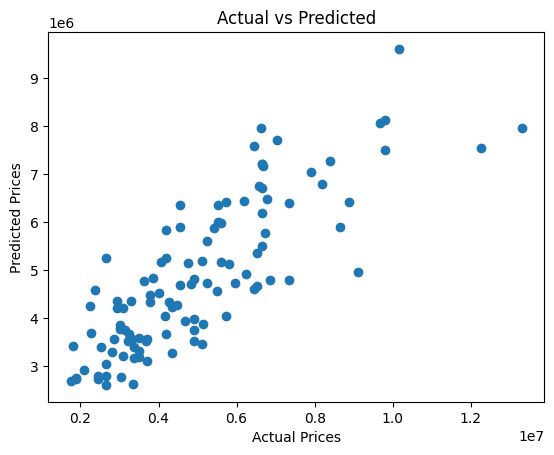

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_lr)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")

plt.show()

In [28]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

In [29]:
mse_ridge = mean_squared_error(
    y_test,
    pred_ridge
)

rmse_ridge = mse_ridge ** 0.5

r2_ridge = r2_score(
    y_test,
    pred_ridge
)

print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge RMSE: 1325320.4441097574
Ridge R2: 0.6524978002155009


In [30]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

In [31]:
mse_lasso = mean_squared_error(
    y_test,
    pred_lasso
)

rmse_lasso = mse_lasso ** 0.5

r2_lasso = r2_score(
    y_test,
    pred_lasso
)

print("Lasso RMSE:", rmse_lasso)
print("Lasso R2:", r2_lasso)

Lasso RMSE: 1324507.0574991899
Lasso R2: 0.6529242131655781


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [33]:
mse_rf = mean_squared_error(
    y_test,
    pred_rf
)

rmse_rf = mse_rf ** 0.5

r2_rf = r2_score(
    y_test,
    pred_rf
)

print("RF RMSE:", rmse_rf)
print("RF R2:", r2_rf)

RF RMSE: 1399769.443949671
RF R2: 0.6123598247296523


In [34]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Random Forest"
    ],

    "RMSE": [
        rmse_lr,
        rmse_ridge,
        rmse_lasso,
        rmse_rf
    ],

    "R2 Score": [
        r2_lr,
        r2_ridge,
        r2_lasso,
        r2_rf
    ]
})

print(results)

               Model          RMSE  R2 Score
0  Linear Regression  1.324507e+06  0.652924
1              Ridge  1.325320e+06  0.652498
2              Lasso  1.324507e+06  0.652924
3      Random Forest  1.399769e+06  0.612360
